# Application Example: Calculate the Depths of Offshore Wind Turbines from Raster and Vector Data Sources.

This example illustrates how to calculate the depths of offshore wind turbines in the North Sea. It showcases Geokit's capabilities in combining multiple geodata sources, whether raster or vector, to conduct analyses in a concise, simple and reproducible way. First, the extent of the North Sea is determined using vector data stored in a shapefile (.shp). Then, the potential positions of offshore turbines in 2050 are located within the North Sea using a second shapefile (.shp). Finally, the depths at the turbine positions are extracted from bathymetry data, which is provided as raster data in GeoTIFF format (.tif). All intermediate results are visualised.

The Major steps are:

1. Data Preparation and Script Setup
2. Load, Extract and Display the Region of the North Sea Based on Sea Basin Vector data
3. Match Bathymetry Raster Data to Vector Sea Basin Data
4. Load and Display the Offshore Wind Turbine Location
5. Extract Water Depths at Offshore Turbine Locations

## 1. Data Preparation and Script Setup

First all required libraries must be imported and the necessary input data must be downloaded

### 1.1. Import all required Libraries

In [ ]:
### Import the necessary libraries
import pathlib

import pooch
from pooch import Unzip

import geokit as gk

current_working_directory = pathlib.Path.cwd()
root_directory = current_working_directory.parent
data_directory = root_directory.joinpath("geokit", "data")

### 1.2 Download Input Data

The required input data for this example has now been downloaded. This download is conducted automatically, so there is no need to visit any external websites.

### 1.2.1. Download Sea Basin Data

This data is used to determine the shape and size of the North Sea. For this purpose, a shapefile from 'IHO Sea Areas, version 3' is used, which can be found here:
https://doi.org/10.14284/323 .
The dataset is available under a CC BY-NC-SA 4.0 licence. You are not permitted to upload the data elsewhere.

In [2]:
# Name of the archive file
sea_basin_file_name_archive = r"iho.zip"

# Configure the extraction of the iho archive
# Extract the shapefiles into a folder called iho
unpack_sea_basins = Unzip(extract_dir=data_directory.joinpath("iho"))

# Increase the download timeout in case the data servers are busy
pooch.downloaders.DEFAULT_TIMEOUT = 1000
# Download and cache the data using the pooch library
pooch.retrieve(
    url="https://geo.vliz.be/geoserver/wfs?request=getfeature&service=wfs&version=1.0.0&typename=MarineRegions:iho&outputformat=SHAPE-ZIP",
    known_hash=None,
    processor=unpack_sea_basins,
    progressbar=False,
    path=data_directory,
    fname=sea_basin_file_name_archive,
)

# Store the path to the sea basin shape file for easy access later
sea_basin_file_name = r"iho.shp"
path_to_sea_basins = str(data_directory.joinpath("iho", sea_basin_file_name))
path_to_sea_basins

'c:\\Programming\\geokit\\geokit\\data\\iho\\iho.shp'

### 1.2.2. Download Offshore Wind Turbine Location Dataset

Waldman et al. provided a dataset showing the potential locations for offshore wind turbines in the North Sea in 2050. This dataset can be accessed via this URL:
https://zenodo.org/records/10259046 . These locations are used to determine the depth of offshore wind turbines in the North Sea by 2050.

In [3]:
# Store the address of the repository for the
# offshore turbine locations and the data download folder

turbine_location_handler = pooch.create(
    path=data_directory,
    base_url="doi:10.5281/zenodo.10259046/",
    registry={"turbine_locations shapefile.zip": "md5:645d553466b33b81b8e0df94f3ec077a"},
    retry_if_failed=5,
)

unpack_turbine_locations_archive = Unzip(extract_dir=data_directory.joinpath("turbine_locations_shapefile"))
turbine_location_handler.fetch(fname="turbine_locations shapefile.zip", processor=unpack_turbine_locations_archive)
offshore_wind_points_path = data_directory.joinpath("turbine_locations_shapefile", "turbine_locations.shp")
assert offshore_wind_points_path.exists()
print(offshore_wind_points_path)

c:\Programming\geokit\geokit\data\turbine_locations_shapefile\turbine_locations.shp


### 1.2.3. Download Bathymetry Data for the North Sea

This section explains how to download bathymetry data for the North Sea. Bathymetry data measures the depth of the sea and is provided as raster data. These data were originally provided by the GEBCO (General Bathymetric Chart of the Oceans) Compilation Group (2020) and can be found using the following DOI: doi:10.5285/a29c5465-b138-234d-e053-6c86abc040b9. For this example, a pre-processed subset of the original data with smaller tiles is used, which can be found here: DOI: https://doi.org/10.5281/zenodo.17047388. This reduces the file size from several gigabytes to a few megabytes.

In [4]:
bathymetry_data_handler = pooch.create(
    path=data_directory,
    base_url="doi:10.5281/zenodo.17047388/",
    registry={"gebco_tiles.zip": "md5:d04c1abd0f531fc3dcf08982ef1ae931"},
    retry_if_failed=5,
)

bathymetry_rasters_dir = str(data_directory.joinpath("gebco_tiles"))
# Fetch one of the files in the repository
unpack_zones_archive = Unzip(extract_dir=bathymetry_rasters_dir)
# Download and cache the offshore gebco dataset
bathymetry_data_handler.fetch("gebco_tiles.zip", processor=unpack_zones_archive)

['c:\\Programming\\geokit\\geokit\\data\\gebco_tiles\\gebco_2020_n90.0_s-90.0_w-180.0_e180.0_03_07.tif',
 'c:\\Programming\\geokit\\geokit\\data\\gebco_tiles\\gebco_2020_n90.0_s-90.0_w-180.0_e180.0_03_08.tif',
 'c:\\Programming\\geokit\\geokit\\data\\gebco_tiles\\gebco_2020_n90.0_s-90.0_w-180.0_e180.0_03_09.tif',
 'c:\\Programming\\geokit\\geokit\\data\\gebco_tiles\\gebco_2020_n90.0_s-90.0_w-180.0_e180.0_03_10.tif',
 'c:\\Programming\\geokit\\geokit\\data\\gebco_tiles\\gebco_2020_n90.0_s-90.0_w-180.0_e180.0_03_11.tif',
 'c:\\Programming\\geokit\\geokit\\data\\gebco_tiles\\gebco_2020_n90.0_s-90.0_w-180.0_e180.0_04_08.tif',
 'c:\\Programming\\geokit\\geokit\\data\\gebco_tiles\\gebco_2020_n90.0_s-90.0_w-180.0_e180.0_04_09.tif',
 'c:\\Programming\\geokit\\geokit\\data\\gebco_tiles\\gebco_2020_n90.0_s-90.0_w-180.0_e180.0_04_10.tif']

## 2. Load, Extract and Display the Region of the North Sea Based on Sea Basin Vector data

In this section the shape and location of the North Sea is extracted from the sea basin shape file.

In [5]:
# Load and display Sea basin data
# As the Sea Basins Shapefile contains all the world's sea basins, we first need to extract the vector for the North Sea using the ExtractFeatures method.
sea_basins = gk.vector.extractFeatures(source=path_to_sea_basins, where="NAME='North Sea'")

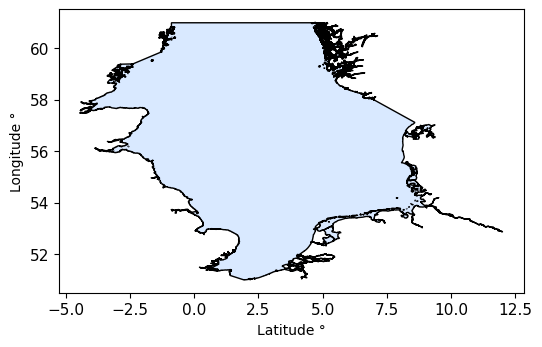

In [ ]:
import matplotlib.pyplot as plt

fig1, ax1 = plt.subplots(figsize=(6, 6))

# The extracted shape file is then shown for inspection

axh1 = gk.drawGeoms(
    sea_basins, srs=gk.srs.EPSG4326, figsize=(6, 6), fontsize=11, draw_cbar=False, simplificationFactor=None, ax=ax1
)

axh1.ax.set_ylabel("Longitude °")
axh1.ax.set_xlabel("Latitude °")

output_path_to_figure_1 = current_working_directory.joinpath("north_seah_basin_example_7.svg")
fig1.savefig(fname=output_path_to_figure_1, bbox_inches="tight")

## 3. Match Bathymetry Raster Data to Vector Sea Basin Data

Firstly, select the raster data tiles that overlap with the North Sea basin by using an 'Extent' object. This enables you to compare the extent of the vector and raster data. The overlapping tiles must then be combined into a single raster. This combined raster can then be warped to the North Sea Basin vector using a 'Region Mask' object. Finally, all the combined data sources are visualised in a single image.

### 3.1. Select and Merge all Relevant Bathymetry Tiles Into a Single Raster

The extent object is used to filter out all the irrelevant tiles. However, the original bathymetry dataset has already had unnecessary tiles removed to reduce the download size. All tiles that overlap the North Sea Basin are then combined into a single raster file called 'bathymetry_raster_NorthSea.tif'.


In [8]:
# Check GEBCO tiles that overlap with the North Sea basin
# Create Extent Instance from North Sea Basin Polygon
north_sea_basin_extent = gk.Extent.fromGeom(sea_basins.loc[0, "geom"])

# Filter for all Bathymetry raster tiles that are located within the basin
bathymetry_datasets = list(north_sea_basin_extent.filterSources(bathymetry_rasters_dir + "/*.tif"))
# Print path to all relevant datasets tiles from the input data
bathymetry_datasets

['c:\\Programming\\geokit\\geokit\\data\\gebco_tiles\\gebco_2020_n90.0_s-90.0_w-180.0_e180.0_03_08.tif',
 'c:\\Programming\\geokit\\geokit\\data\\gebco_tiles\\gebco_2020_n90.0_s-90.0_w-180.0_e180.0_03_09.tif',
 'c:\\Programming\\geokit\\geokit\\data\\gebco_tiles\\gebco_2020_n90.0_s-90.0_w-180.0_e180.0_04_08.tif',
 'c:\\Programming\\geokit\\geokit\\data\\gebco_tiles\\gebco_2020_n90.0_s-90.0_w-180.0_e180.0_04_09.tif']

## 3.2 Combine All Relevant Tiles Into a Single Tile

All the tiles that were previously selected are now combined into a single raster file called: 'bathymetry_raster_NorthSea.tif'.

In [9]:
# Define path to combined raster file
path_to_bathymetry_file = current_working_directory.joinpath("bathymetry_raster_NorthSea.tif")
path_to_bathymetry_file_str = str(path_to_bathymetry_file)

# Combine the GEBCO tiles to a single tile
bathymetry_raster = gk.algorithms.combineSimilarRasters(bathymetry_datasets, output=path_to_bathymetry_file_str)

C:\Programming\geokit\geokit\_algorithms\combineSimilarRasters.py:271: UserWarning: WARNING: Overwriting existing output file. Sometimes writing to an non empty output fails. Recommended to write to a non existing location instead and include maser into datasets.
  warn(


2025-11-25 22:57:22.213848 Now adding raster No. 1/4
2025-11-25 22:57:23.821135 Now adding raster No. 2/4
2025-11-25 22:57:25.475096 Now adding raster No. 3/4
2025-11-25 22:57:27.210148 Now adding raster No. 4/4


## 3.3. Warp Bathymetry Raster Data to Vector Data of The North Sea

To put bathymetry raster data in relation to vector sea basin data, the raster data must be warped into vector data. A RegionMask object is therefore used.

In [10]:
GEBCO_rasterInfo = gk.raster.rasterInfo(path_to_bathymetry_file_str)

assert GEBCO_rasterInfo.pixelHeight == GEBCO_rasterInfo.pixelWidth, (
    "Pixel height and width must be equal. Consider warping the raster to a square pixel size."
)

# create a region mask
northSeaMask = gk.RegionMask.fromGeom(sea_basins.geom[0], srs=gk.srs.EPSG4326, pixelRes=GEBCO_rasterInfo.pixelHeight)
# warp the region mask onto the GEBCO raster
northSeaRasterWarped = northSeaMask.warp(
    source=path_to_bathymetry_file_str,
    returnMatrix=False,
)

## 3.4. Display the Combination of the North Sea Vector and the Bathymetry Data
Display the section of the bathymetry raster data that lies within the North Sea 

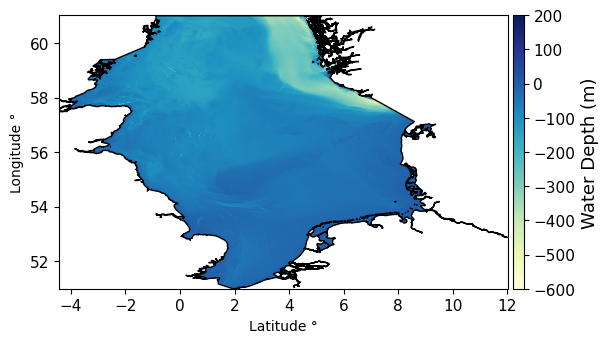

In [11]:
# draw the the GEBCO raster in the North Sea
fig2, ax2 = plt.subplots(figsize=(6, 6))


axh2_raster = gk.drawRaster(
    source=northSeaRasterWarped,
    srs=gk.srs.EPSG4326,
    cmap="YlGnBu",
    vmin=-600,
    vmax=200,
    fontsize=11,
    ax=ax2,
    cbar=True,
    cbarTitle="Water Depth (m)",
)
# plt.colorbar(axh.handles, cax=cax, label="Water Depth (m)")
axh2 = gk.drawGeoms(sea_basins, srs=gk.srs.EPSG4326, ax=axh2_raster, fc="none", fontsize=11, simplificationFactor=None)
axh2.ax.set_ylabel("Longitude °")
axh2.ax.set_xlabel("Latitude °")
output_path_to_figure_2 = current_working_directory.joinpath("bathymetry_example_7.svg")
fig2.savefig(fname=output_path_to_figure_2, bbox_inches="tight")

## 4. Load and Display the Offshore Wind Turbine Location

In this section, the locations of offshore wind turbines are loaded and displayed on a vector map of the North Sea basin.

In [12]:
# Load the offshore wind turbine locations
offshore_wind_points = gk.vector.extractFeatures(source=str(offshore_wind_points_path))

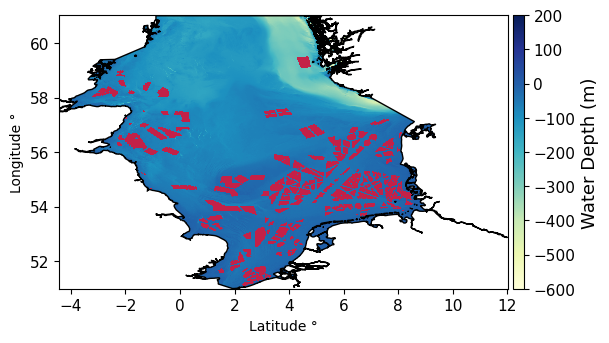

In [13]:
# Display the offshore wind turbines on a vector map of the North Sea basin.
fig3, ax3 = plt.subplots(figsize=(6, 6))


axh3_raster = gk.drawRaster(
    source=northSeaRasterWarped,
    srs=gk.srs.EPSG4326,
    figsize=(6, 6),
    vmin=-600,
    vmax=200,
    fontsize=11,
    cbar=True,
    ax=ax3,
    cmap="YlGnBu",
    cbarTitle="Water Depth (m)",
)


axh3_seabasin = gk.drawGeoms(
    sea_basins,
    srs=gk.srs.EPSG4326,
    ax=axh3_raster,
    fc="none",
    fontsize=11,
    simplificationFactor=None,
)
axh3_complete = gk.drawGeoms(
    offshore_wind_points,
    srs=gk.srs.EPSG4326,
    ax=axh3_seabasin,
    fontsize=11,
    simplificationFactor=None,
    marker=",",
)


axh3_complete.ax.set_ylabel("Longitude °")
axh3_complete.ax.set_xlabel("Latitude °")
output_path_to_figure_3 = current_working_directory.joinpath("complete_figure_example_7.svg")
fig3.savefig(fname=output_path_to_figure_3, bbox_inches="tight")

## 5. Extract Water Depths at Offshore Turbine Locations  

Finally, the water depth at the location of each offshore wind turbine is calculated. As the raster bathymetry data was not measured directly at the positions of the offshore turbines, it is necessary to interpolate the depths between multiple bathymetry measurements. This is achieved using the 'InterpolateValues' method.

In [14]:
# Define a function that interpolates the depth of bathymetry measurements based on a given offshore turbine location.
def interpolate_turbine_data(turbine_location):
    offshore_point = gk.raster.interpolateValues(
        source=northSeaRasterWarped, points=turbine_location, pointSRS=gk.srs.EPSG4326
    )
    return offshore_point


# Apply the interpolation function to the offshore turbine locations
offshore_wind_points["depth"] = offshore_wind_points.geom.apply(interpolate_turbine_data)

C:\Programming\geokit\geokit\core\raster.py:1093: UserWarning: WARNING: 1 of the given points (or extraction windows) exceed/s the source's limits. Values were replaced with nan.
  warnings.warn(msg, UserWarning)


In [15]:
offshore_wind_points

,geom,Latitude,Longitude,Source,Year,Capacity,depth
0,POINT (2.89073366853241 51.5909205034472),51.590921,2.890734,DOWT,NaN,NaN,-32.0
1,POINT (2.89980665290202 51.5951425852826),51.595143,2.899807,DOWT,NaN,NaN,-32.0
2,POINT (2.89729137010649 51.5863390954982),51.586339,2.897291,DOWT,NaN,NaN,-30.0
3,POINT (2.9049270500215 51.5815780244924),51.581578,2.904927,DOWT,NaN,NaN,-27.0
4,POINT (2.9297205518632 51.5683727898158),51.568373,2.929721,DOWT,NaN,NaN,-25.0
...,...,...,...,...,...,...,...
19600,POINT (4.18869621504974 55.2748544843796),55.274854,4.188696,Future,2050.0,27.0,-44.0
19601,POINT (4.16493714915397 55.2617389579867),55.261739,4.164937,Future,2050.0,27.0,-44.0
19602,POINT (4.18949392747561 55.3015357733419),55.301536,4.189494,Future,2050.0,27.0,-42.0
19603,POINT (4.16571853778764 55.288420532223),55.288421,4.165719,Future,2050.0,27.0,-42.0


This data can be used to analyse the investment costs of these wind turbines. However, this is just an example to demonstrate the potential of Geokit for data exploration and analysis.